# Лабораторная работа №1.1: Первичное исследование и оценка качества данных

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data1_1/movies.csv')

## 1) Типы признаков и шкалы измерения

### Задание 1.
#### 1. Типы шкал измерения для каждого признака датасета:
| Признак  | Тип шкалы    |
|----------|--------------|
| name     | номинальная  |
| rating   | номинальная  |
| genre    | номинальная  |
| year     | интервальная |
| released | номинальная  |
| score    | интервальная |
| votes    | абсолютная   |
| director | номинальная  |
| star     | номинальная  |
| country  | номинальная  |
| budget   | абсолютная   |
| gross    | абсолютная   |
| company  | номинальная  |
| runtime  | абсолютная   |
#### 2. Анализ двух признаков с разными шкалами:
Выберем для анализа:
- `rating` (номинальная шкала)
- `score` (интервальная шкала)

In [3]:
print('score:')
print(f'Среднее: ', df['score'].mean().round(4))
print(f'Медиана: ', df['score'].median())
print(f'Мода: ', df['score'].mode().values[0])
print()

print('rating:')
print('Среднее: Нет')
print('Медиана: Нет')
print(f'Мода:', df['rating'].mode().values[0])
print()

print('Вывод: Для номинальных признаков считать можно только моду (самое частое значение). Среднее и медиану считать методологически неверно. Но для интервальной шкалы  вычисление среднего, медианы и моды имеет смысл.')

score:
Среднее:  6.394
Медиана:  6.5
Мода:  6.6

rating:
Среднее: Нет
Медиана: Нет
Мода: R

Вывод: Для номинальных признаков считать можно только моду (самое частое значение). Среднее и медиану считать методологически неверно. Но для интервальной шкалы  вычисление среднего, медианы и моды имеет смысл.


## 2)  Пропуски и их природа (MCAR / MAR / MNAR)

### Задание 2. Диагностика типа пропусков

Выберем признак `budget`, так как у него значительный процент пропусков (28.54%).


In [18]:
print(f"Количество пропусков: {df['budget'].isnull().sum()}")
print(f"Процент пропусков: {(df['budget'].isnull().sum() / len(df) * 100).round(2)}%")
print()

print("Гипотеза 1: Пропуски - MCAR (Случайно)")
print("  Нет корреляции с другими признаками. Пропуски случайны.")
print("Гипотеза 2: Пропуски - MAR (Зависит от других наблюдаемых признаков)")
print("  Связаны с рейтингом, жанром, годом выпуска, кассовыми сборами.")
print("Гипотеза 3: Пропуски - MNAR (Зависит от самого бюджета)")
print("  Бюджеты фильмов могут намеренно не раскрываться, особенно у малобюджетных или сверхдорогих картин.")
print()

print("Проверки гипотез: сравниваем признаки с пропусками vs без пропусков")

missing_budget = df['budget'].isnull()

print("Средние кассовые сборы (gross):")
print(f"С пропусками budget: {df[missing_budget]['gross'].mean():.2f}")
print(f"Без пропусков budget: {df[~missing_budget]['gross'].mean():.2f}")

print("\nСредние рейтинги (score):")
print(f"С пропусками budget: {df[missing_budget]['score'].mean():.2f}")
print(f"Без пропусков budget: {df[~missing_budget]['score'].mean():.2f}")

print("\nСравнение по рейтингам (rating)")
rating_freq_missing = df[missing_budget]['rating'].value_counts()
rating_freq_all = df['rating'].value_counts()


print("Доля пропусков по рейтингам (где >1% от общего):")
for rating in rating_freq_all.index:
    count_missing = rating_freq_missing.get(rating, 0)
    count_all = rating_freq_all[rating]
    share_missing = (count_missing / count_all * 100).round(1)
    if share_missing > 1.0:
        print(f"{rating}: {count_missing} пропусков ({share_missing}%) из {count_all} фильмов")

print("\nСравнение по жанрам (genre)")
genre_freq_missing = df[missing_budget]['genre'].value_counts()
genre_freq_all = df['genre'].value_counts()

top_genres = genre_freq_all.head(10).index
print("Доля пропусков по топ-10 жанрам:")
for genre in top_genres:
    count_missing = genre_freq_missing.get(genre, 0)
    count_all = genre_freq_all[genre]
    share_missing = (count_missing / count_all * 100).round(1)
    if share_missing > 1.0:
        print(f"{genre}: {count_missing} пропусков ({share_missing}%) из {count_all} фильмов")

print("\nСравнение по периодам лет (десятилетия)")
df['decade'] = (df['year'] // 10) * 10
missing_budget = df['budget'].isnull()
year_freq_missing = df[missing_budget].groupby('decade').size()
year_freq_all = df.groupby('decade').size()

print("Доля пропусков по десятилетиям:")
for decade in sorted(year_freq_all.index):
    count_missing = year_freq_missing.get(decade, 0)
    count_all = year_freq_all[decade]
    share_missing = (count_missing / count_all * 100).round(1)
    print(f"{int(decade)}-е: {count_missing} пропусков ({share_missing}%) из {count_all} фильмов")

Количество пропусков: 2282
Процент пропусков: 28.54%

Гипотеза 1: Пропуски - MCAR (Случайно)
  Нет корреляции с другими признаками. Пропуски случайны.
Гипотеза 2: Пропуски - MAR (Зависит от других наблюдаемых признаков)
  Связаны с рейтингом, жанром, годом выпуска, кассовыми сборами.
Гипотеза 3: Пропуски - MNAR (Зависит от самого бюджета)
  Бюджеты фильмов могут намеренно не раскрываться, особенно у малобюджетных или сверхдорогих картин.

Проверки гипотез: сравниваем признаки с пропусками vs без пропусков
Средние кассовые сборы (gross):
С пропусками budget: 13396415.78
Без пропусков budget: 104177255.61

Средние рейтинги (score):
С пропусками budget: 6.40
Без пропусков budget: 6.39

Сравнение по рейтингам (rating)
Доля пропусков по рейтингам (где >1% от общего):
R: 1128 пропусков (29.2%) из 3866 фильмов
PG-13: 376 пропусков (17.5%) из 2148 фильмов
PG: 370 пропусков (27.3%) из 1354 фильмов
Not Rated: 241 пропусков (83.1%) из 290 фильмов
G: 45 пропусков (28.3%) из 159 фильмов
Unrated: 34

#### Вывод:
Пропуски в `budget` относятся к типу MAR (Missing At Random) преимущественно, с возможными элементами MNAR.

**MCAR – маловероятен, так как выявлена чёткая зависимость доли пропусков от других наблюдаемых признаков:**
- по рейтингу: от 17,5% (`PG-13`) до 83% (`Not Rated`);
- по жанру: от 16% (`Action`) до 42% (`Drama`);
- по году: от 17% (`2000‑е`) до 44% (`1980‑е`);
- по кассовым сборам: у фильмов с пропущенным бюджетом сборы в 8 раз ниже.

**MAR – наиболее вероятен, так как наличие/отсутствие бюджета можно объяснить наблюдаемыми характеристиками:**
- независимые фильмы (`Not Rated`, `Unrated`) чаще не раскрывают бюджет;
- в драмах и комедиях пропусков больше, чем в боевиках;
- в ранние годы (`1980‑е`) данные о бюджете фиксировались хуже;
- низкие сборы коррелируют с отсутствием информации о бюджете.

**MNAR – не может быть полностью исключён, поскольку возможна ситуация, когда пропуски связаны с самим значением бюджета (например, слишком малобюджетные или очень дорогие фильмы намеренно не публикуют эту информацию).**

### Задание 3. Индикатор пропуска как источник информации

#### 1. Когда факт пропуска несет информацию?

Факт пропуска несёт информацию при MAR/MNAR, когда отсутствие значения связано с другими признаками.

#### 2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой импутации?

Значимость индикатора в модели показывает, что простое заполнение медианой не уловило закономерности. Модель использует факт пропуска, а не заполненное значение `budget`. Это сигнал улучшить импутацию.

#### 3. Пример признака, для которого индикатор пропуска полезен, бесполезен, опасен.
- Полезен: при MNAR, когда пропуск несет информацию (например, фильмы с пропущенным бюджетом (`budget`) в среднем имеют низкие сборы, и добавление этого индикатора в модель может улучшить прогноз кассовых успехов)
- Бесполезен: при MCAR, когда пропуск не несет информации (например, пропуск названия (`name`) - это техническая ошибка, не несёт смысла)
- Опасен: когда пропуск - неточный индикатор информации, на основании которого модель может делать неверные выводы (например, если в данных всего 2% пропусков, а модель находит сильную связь индикатора с успешностью фильма, можно ошибочно заключить, что пропуск бюджета – признак высоких сборов, хотя на самом деле это артефакт выборки
)

## 3)  Выбросы

### Задание 4. Выброс - это ошибка или сигнал?

Для примера возьмем признак `gross` и выброс с наименьшим значением (0)


In [19]:
min_gross = df['gross'].min()
print(f"Минимальные сборы: {min_gross}")

df[df['gross'] == min_gross][['name', 'gross']]

Минимальные сборы: 0.0


,name,gross
407,Educating Rita,0.0
2557,Shadowlands,0.0
4545,The Haunted Mansion,0.0
7825,Shed of the Dead,0.0
7827,Junglee,0.0


#### 1. Реальные причины значения:

Кассовые сборы фильмов не могут быть нулевыми (даже при полном провале сборы обычно выше нуля, что явно указывает на техническую ошибку ввода данных). Нулевые или отрицательные сборы не имеют экономического смысла.

#### 2. Сравнение стратегий обработки:
- УДАЛИТЬ: наилучший вариант, так как это явная ошибка ввода, а потеря одной записи — некритично.
- ОСТАВИТЬ: плохой вариант, исказит статистику (средние сборы) и повлияет на визуализацию.
- ПРЕОБРАЗОВАТЬ: неэффективно, преобразования не исправляют опечатки и не могут превратить ноль в осмысленное значение..

## 4)  Статистики

### Задание 5. Преобразование или винзоризация?

Логарифмирование предпочтительно, когда имеется сильная правосторонняя асимметрия или выбросы. Работает только с положительными числами.

Корень предпочтителен при умеренной асимметрии и наличии нулей. Сохраняет единицы измерения.

Винзоризация предпочтительна, когда нужно убрать влияние выбросов, но при этом важно сохранить исходное распределение.

Влияние подходов:

|                    | Логарифмирование                                          | Корень                        | Винзоризация                               |
|--------------------|-----------------------------------------------------------|-------------------------------|--------------------------------------------|
| Интерпретируемость | Сложная                                                   | Средняя                       | Высокая                                    |
| Линейные модели    | Нормализует отклонения                                    | Умеренно улучшает             | Улучшает за счет снижения влияния выбросов |
| Визуализация       | Сжимает большие значения, компактный график, видны детали | Умеренное сжатие правого края | Почти не меняет форму, обрезает края       |

Исходные данные (budget):
Среднее: 35560005.15
Медиана: 20000000.00
Асимметрия: 2.46
Эксцесс: 7.41
Мин: 3000, Макс: 356000000

Логарифмирование:
Среднее: 16.74
Асимметрия: -1.19

Квадратный корень:
Среднее: 5175.92
Асимметрия: 1.06

Винзоризация (5%):
Среднее: 33406028.60
Асимметрия: 1.55
Мин: 2000000, Макс: 130000000


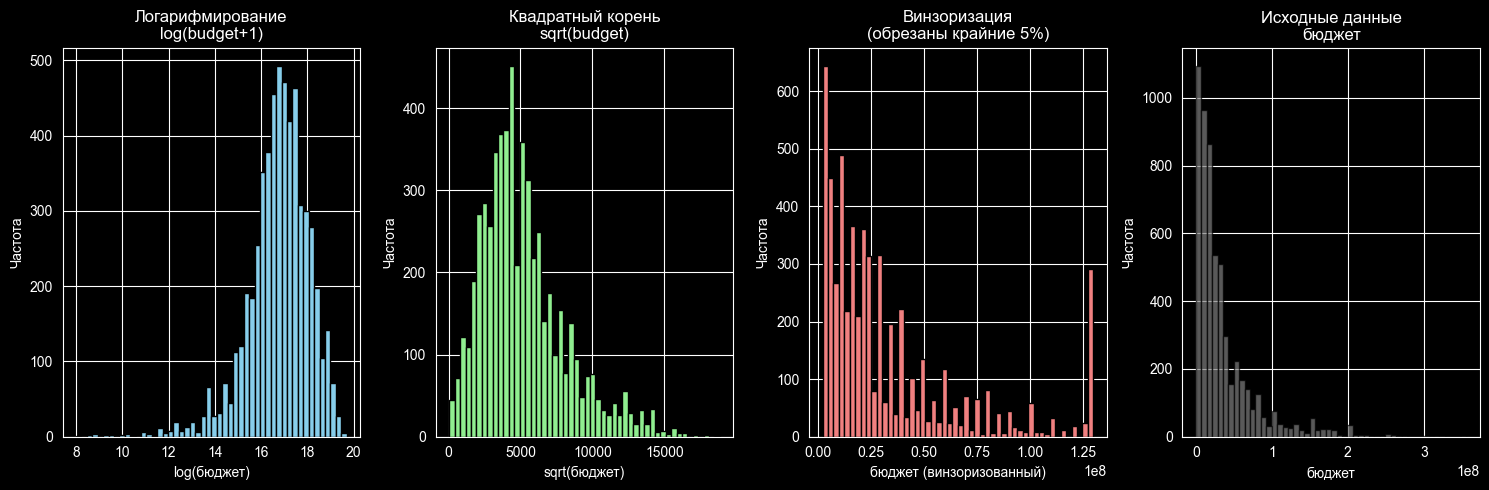

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mstats, skew, kurtosis

budget_data = df['budget'].dropna()
budget_data = budget_data[budget_data > 0].values

print("Исходные данные (budget):")
print(f"Среднее: {budget_data.mean():.2f}")
print(f"Медиана: {np.median(budget_data):.2f}")
print(f"Асимметрия: {skew(budget_data):.2f}")
print(f"Эксцесс: {kurtosis(budget_data):.2f}")
print(f"Мин: {budget_data.min():.0f}, Макс: {budget_data.max():.0f}\n")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# 1. Логарифмирование
log_budget = np.log1p(budget_data)
axes[0].hist(log_budget, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Логарифмирование\nlog(budget+1)')
axes[0].set_xlabel('log(бюджет)')
axes[0].set_ylabel('Частота')
print("Логарифмирование:")
print(f"Среднее: {log_budget.mean():.2f}")
print(f"Асимметрия: {skew(log_budget):.2f}\n")

# 2. Квадратный корень
sqrt_budget = np.sqrt(budget_data)
axes[1].hist(sqrt_budget, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Квадратный корень\nsqrt(budget)')
axes[1].set_xlabel('sqrt(бюджет)')
axes[1].set_ylabel('Частота')
print("Квадратный корень:")
print(f"Среднее: {sqrt_budget.mean():.2f}")
print(f"Асимметрия: {skew(sqrt_budget):.2f}\n")

# 3. Винзоризация (обрезаем 5% с каждого конца)
winsorized_budget = mstats.winsorize(budget_data, limits=[0.05, 0.05])
axes[2].hist(winsorized_budget, bins=50, color='lightcoral', edgecolor='black')
axes[2].set_title('Винзоризация\n(обрезаны крайние 5%)')
axes[2].set_xlabel('бюджет (винзоризованный)')
axes[2].set_ylabel('Частота')
print("Винзоризация (5%):")
print(f"Среднее: {winsorized_budget.mean():.2f}")
print(f"Асимметрия: {skew(winsorized_budget):.2f}")
print(f"Мин: {winsorized_budget.min():.0f}, Макс: {winsorized_budget.max():.0f}")

axes[3].hist(budget_data, bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[3].set_title('Исходные данные\nбюджет')
axes[3].set_xlabel('бюджет')
axes[3].set_ylabel('Частота')

plt.tight_layout()
plt.show()

### Задание 6. Средние, которые вводят в заблуждение

Рассмотрим числовой признак `gross` (кассовые сборы в долларах США)
Для расчёта использованы только положительные значения, так как геометрическое среднее не определено для нулей и отрицательных чисел.

In [7]:
from scipy import stats

gross_data = df['gross'].dropna()
gross_positive = gross_data[gross_data > 0]
print("Арифметическое среднее:", round(gross_positive.mean(), 2))
print("Медиана:", round(gross_positive.median(), 2))
print("Геометрическое среднее (без сдвига):", round(stats.gmean(gross_positive), 2))

Арифметическое среднее: 79210049.75
Медиана: 20240315.0
Геометрическое среднее (без сдвига): 15832035.54


#### Почему средние различаются?

Арифметическое среднее оказалось почти в 4 раза выше медианы. Это объясняется сильной правосторонней асимметрией распределения кассовых сборов. Несколько фильмов-блокбастеров (например, «Аватар», «Мстители: Финал», «Титаник») имеют сборы, превышающие 1 млрд $, что резко сдвигает среднее арифметическое вверх, делая его нерепрезентативным для большинства фильмов.

Медиана устойчива к выбросам и показывает, что половина фильмов собрала менее 20,2 млн $, а половина — более. Это значение ближе к реальному «типичному» фильму.

Геометрическое среднее (≈15,8 млн $) также устойчиво к выбросам, но оно отражает мультипликативный центр распределения. Оно оказалось ниже медианы из-за того, что в данных присутствуют фильмы с очень низкими сборами, которые сильнее влияют на геометрическое среднее, чем на медиану.

#### Какое из средних лучше отражает «типичное» значение и почему?

**Медиана** лучше всего отражает типичный фильм, так как распределение кассовых сборов имеет ярко выраженную асимметрию. Большинство фильмов собирают суммы в десятки миллионов долларов, и лишь единицы достигают сотен миллионов или миллиардов.
Арифметическое среднее искусственно завышено за счёт нескольких блокбастеров и не соответствует реальности для подавляющего большинства фильмов. Геометрическое среднее, хотя и близко к медиане, менее интуитивно понятно и в данном контексте не даёт преимуществ по сравнению с медианой.

## 5 Визуализация как инструмент мышления

### Задание 7. Неправильная диаграмма

Рассмотрим признак `score`(рейтинг IMDb). Для анализа распределения рейтингов была построена гистограмма, которая позволяет увидеть форму распределения (близкое к нормальному, с небольшим левым скосом), частоту значений (пик в районе 6.5–7.5) и выбросы (фильмы с рейтингом ниже 3.0 и выше 9.0).

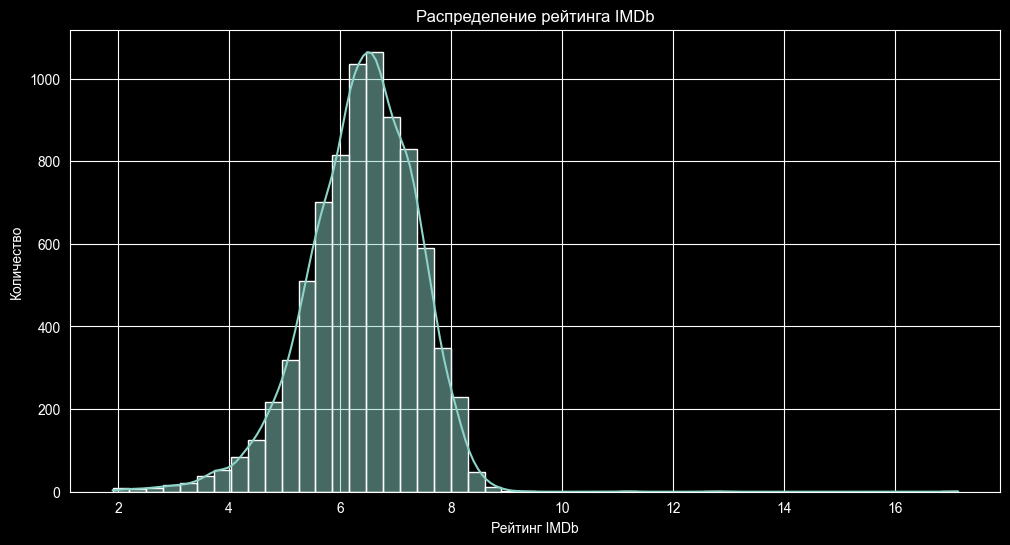

In [8]:
plt.figure(figsize=(12,6))
sns.histplot(df['score'], bins=50, kde=True)
plt.title('Распределение рейтинга IMDb')
plt.xlabel('Рейтинг IMDb')
plt.ylabel('Количество')
plt.show()


**Пример неправильной визуализации.**
Для этих данных можно было бы построить круговую диаграмму, однако такой тип визуализации является неудачным для числовых признаков, т.к. круговая диаграмма предназначена для категориальных данных, а рейтинг является непрерывным числовым признаком. Для её построения пришлось бы произвольно разбить рейтинг на интервалы (например, 0–5, 5–6, 6–7, 7–8, 8–10), что вносит субъективность и теряет точность.

**Какую информацию исказил бы такой график:**

Если построить круговую диаграмму с категориями `0–5`, `5–6`, `6–7`, `7–8`, `8–10` по представленным данным, зритель может ошибочно заключить, что:
- Доля фильмов с рейтингом 8–10 (26,6%) почти равна доле фильмов с рейтингом 6–7 (41,5%), хотя на самом деле последних в **1,5 раза больше**.
- Распределение рейтингов относительно равномерно, тогда как реально **почти половина фильмов (41,5%)** сосредоточена в узком интервале 6–7, а крайние значения (0–5) составляют лишь **8,2%**.
- Фильмов с рейтингом ниже 5 достаточно много, чтобы считаться значимой частью библиотеки, хотя на деле их доля мала (менее 10%).

Таким образом, круговая диаграмма для непрерывного признака `score` не только неинформативна, но и искажает восприятие пропорций. Правильным выбором остаётся гистограмма, которая наглядно показывает реальное распределение с явным пиком в интервале 6–7 и спадами к краям.

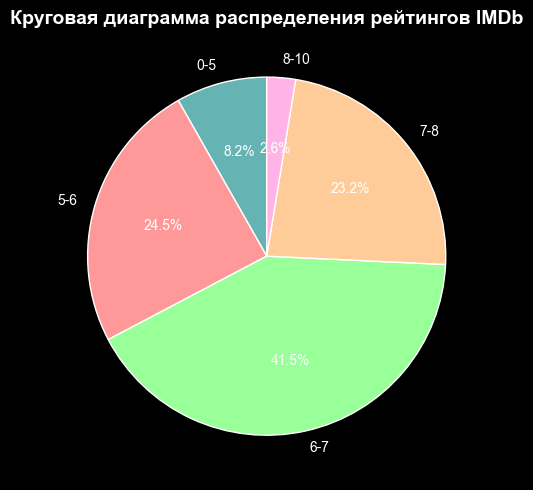

In [9]:
score_bins = pd.cut(df['score'].dropna(),
                    bins=[0, 5, 6, 7, 8, 10],
                    labels=['0-5', '5-6', '6-7', '7-8', '8-10'])
score_counts = score_bins.value_counts().sort_index()

plt.figure(figsize=(5, 5))
plt.pie(score_counts.values,
        labels=score_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3b3', '#ff9999', '#99ff99', '#ffcc99', '#ffb3e6'])
plt.title('Круговая диаграмма распределения рейтингов IMDb', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### Задание 8. Одна и та же информация - разные графики

Рассмотрим признаки `year` (год выпуска) и `rating` (возрастной рейтинг). Для них можно построить визуализации в виде группированной столбчатой диаграммы и ящика с усами (boxplot).

Первый вариант — группированная столбчатая диаграмма, которая показывает динамику изменения структуры возрастных рейтингов в разные эпохи.

Гипотеза: "Резкий рост количества фильмов начался после 1990 года, причём доля PG-13 стала преобладающей"

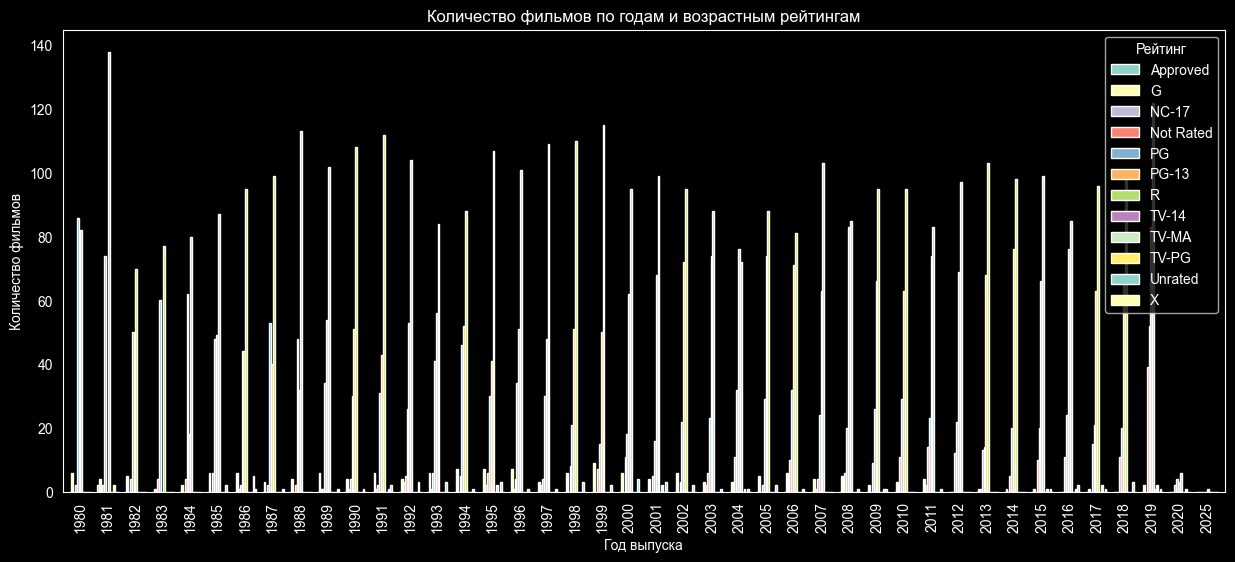

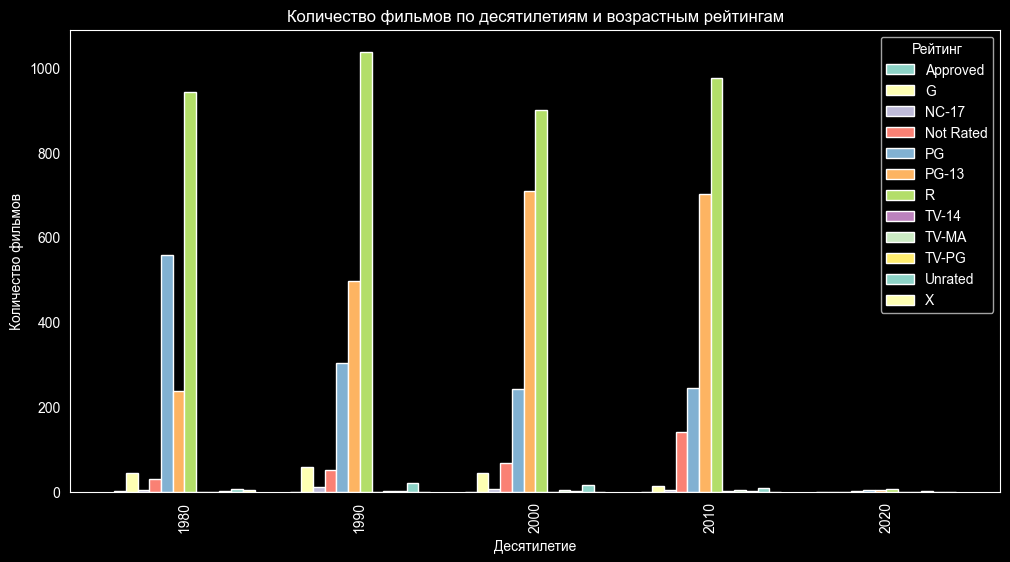

In [10]:
type_year = pd.crosstab(df['year'], df['rating'])

type_year.plot(kind='bar', figsize=(15, 6), width=0.8)
plt.title('Количество фильмов по годам и возрастным рейтингам')
plt.xlabel('Год выпуска')
plt.ylabel('Количество фильмов')
plt.legend(title='Рейтинг')
plt.grid(False)
plt.show()


df['decade'] = (df['year'] // 10) * 10
type_decade = pd.crosstab(df['decade'], df['rating'])

type_decade.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Количество фильмов по десятилетиям и возрастным рейтингам')
plt.xlabel('Десятилетие')
plt.ylabel('Количество фильмов')
plt.legend(title='Рейтинг')
plt.grid(False)
plt.show()

Второй вариант — boxplot (ящик с усами), который показывает медианный год выпуска для фильмов, разброс значений, выбросы.

Гипотеза: "Фильмы с рейтингом PG-13 в среднем новее, чем с R"

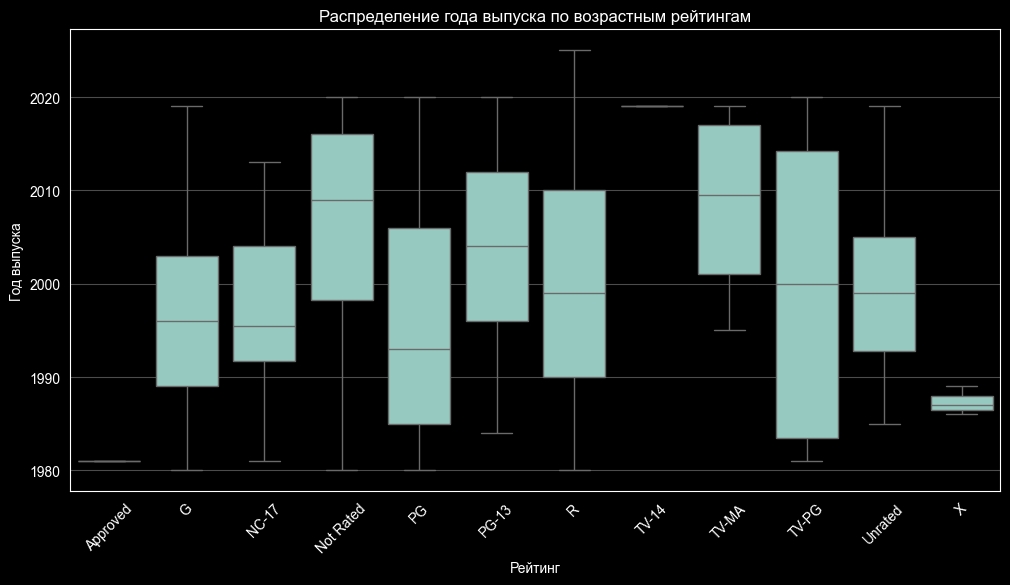

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='rating', y='year', data=df, order=sorted(df['rating'].dropna().unique()))
plt.title('Распределение года выпуска по возрастным рейтингам')
plt.xlabel('Рейтинг')
plt.ylabel('Год выпуска')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Таким образом, использование двух типов визуализации дополняет друг друга: один фокусируется на динамике долей, другой – на распределении непрерывной переменной внутри категорий. Вместе они дают полное представление о взаимосвязи года выпуска и возрастного рейтинга.